# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [8]:
# TODO: Import all necessary libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn models and tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [9]:
# TODO: Load regression dataset
df_reg = pd.read_csv('/content/drive/MyDrive/insurance.csv')

print("Dataset Shape:", df_reg.shape)
print("Column Names:", df_reg.columns.tolist())
print("Target Variable: charges")


Dataset Shape: (1338, 7)
Column Names: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Target Variable: charges


## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


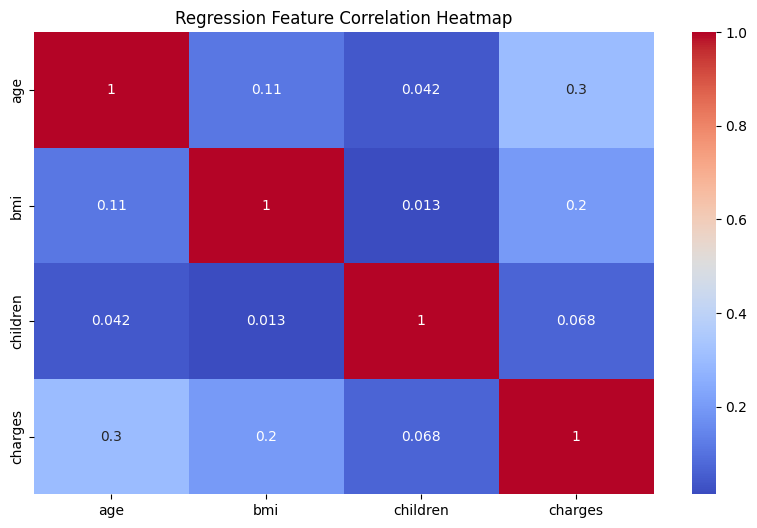

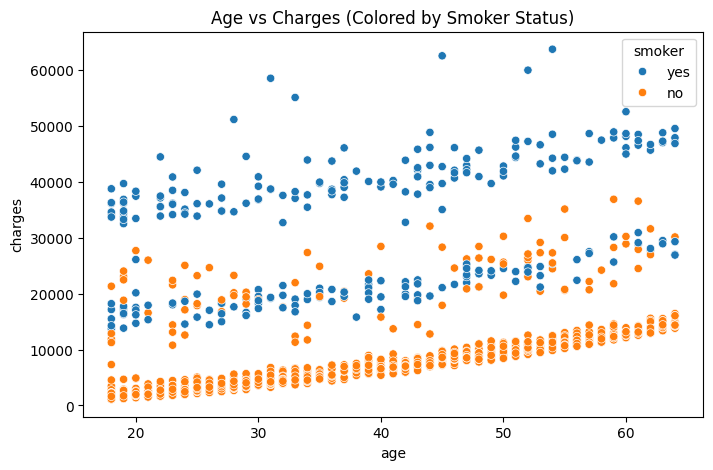

In [10]:
# TODO: Perform EDA
# Show descriptive statistics
display(df_reg.describe())

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_reg.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title("Regression Feature Correlation Heatmap")
plt.show()

# Feature vs Target (Age vs Charges)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='charges', data=df_reg, hue='smoker')
plt.title("Age vs Charges (Colored by Smoker Status)")
plt.show()


## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [11]:
# TODO: Prepare features
# Encoding Categorical Data
df_reg_prep = pd.get_dummies(df_reg, drop_first=True)

X_r = df_reg_prep.drop('charges', axis=1)
y_r = df_reg_prep['charges']

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y_r, test_size=0.2, random_state=42)

# Scaling
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)


## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [12]:
# TODO: Multiple Linear Regression
lr = LinearRegression()
lr.fit(X_train_r_scaled, y_train_r)
y_pred_lr = lr.predict(X_test_r_scaled)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_lr)):.2f}")
print(f"MAE: {mean_absolute_error(y_test_r, y_pred_lr):.2f}")
print(f"R² Score: {r2_score(y_test_r, y_pred_lr):.2f}")

RMSE: 5796.28
MAE: 4181.19
R² Score: 0.78


## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [14]:
# TODO: Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train_r_scaled)
X_poly_test = poly.transform(X_test_r_scaled)

poly_lr = LinearRegression()
poly_lr.fit(X_poly_train, y_train_r)
y_pred_poly = poly_lr.predict(X_poly_test)

print(f"Polynomial R² Score: {r2_score(y_test_r, y_pred_poly):.2f}")

Polynomial R² Score: 0.87


## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [15]:
# TODO: Support Vector Regression
svr = SVR(kernel='rbf')
svr.fit(X_train_r_scaled, y_train_r)
y_pred_svr = svr.predict(X_test_r_scaled)

print(f"SVR R² Score: {r2_score(y_test_r, y_pred_svr):.2f}")

SVR R² Score: -0.07


## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


In [16]:
# TODO: Random Forest Regressor
# n_estimators controls the number of trees
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_r, y_train_r)
y_pred_rf = rf_reg.predict(X_test_r)

print(f"Random Forest R² Score: {r2_score(y_test_r, y_pred_rf):.2f}")

Random Forest R² Score: 0.87


# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [17]:
# TODO: Load classification dataset
df_clf = pd.read_csv('/content/drive/MyDrive/loan_data.csv')

print("Class Distribution:\n", df_clf['loan_status'].value_counts())

Class Distribution:
 loan_status
0    35000
1    10000
Name: count, dtype: int64


## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


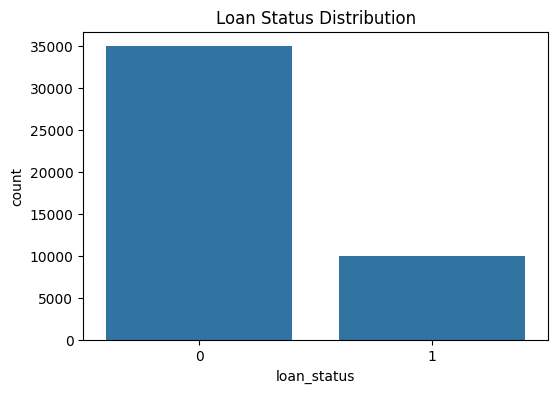

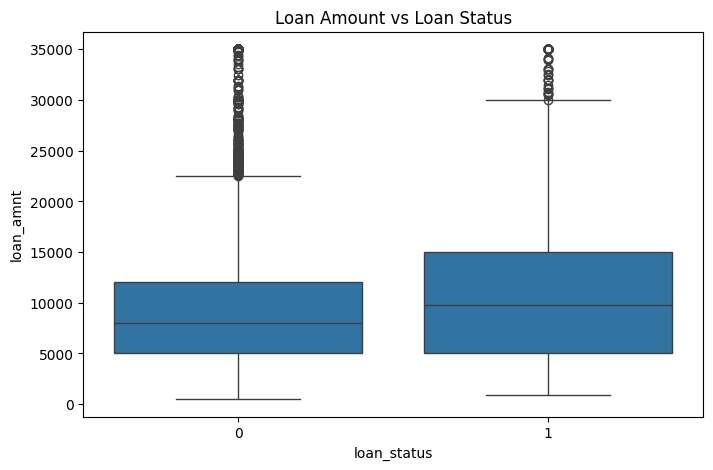

In [18]:
# TODO: Classification EDA
# Plot class counts
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df_clf)
plt.title("Loan Status Distribution")
plt.show()

# Feature vs Class (Loan Amount vs Status)
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_status', y='loan_amnt', data=df_clf)
plt.title("Loan Amount vs Loan Status")
plt.show()

## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [19]:
# TODO: Prepare classification features
# Encoding
le = LabelEncoder()
for col in df_clf.select_dtypes(include=['object']).columns:
    df_clf[col] = le.fit_transform(df_clf[col])

X_c = df_clf.drop('loan_status', axis=1)
y_c = df_clf['loan_status']

# Train-test split with stratification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, stratify=y_c, random_state=42)

# Scaling
sc_c = StandardScaler()
X_train_c_scaled = sc_c.fit_transform(X_train_c)
X_test_c_scaled = sc_c.transform(X_test_c)

## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


In [20]:
# TODO: Logistic Regression
log_reg = LogisticRegression(penalty='l2', random_state=42)
log_reg.fit(X_train_c_scaled, y_train_c)
y_pred_log = log_reg.predict(X_test_c_scaled)

print(f"Accuracy: {accuracy_score(y_test_c, y_pred_log):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_c, y_pred_log))

Accuracy: 0.90
Confusion Matrix:
 [[6572  428]
 [ 501 1499]]


## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


In [21]:
# TODO: SVM Classification
svm_clf = SVC(kernel='linear', random_state=42)
svm_clf.fit(X_train_c_scaled, y_train_c)
print(f"SVM Accuracy: {svm_clf.score(X_test_c_scaled, y_test_c):.2f}")

SVM Accuracy: 0.90


## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



In [ ]:
# TODO: Naive Bayes
nb = GaussianNB()
nb.fit(X_train_c_scaled, y_train_c)
print(f"Naive Bayes Accuracy: {nb.score(X_test_c_scaled, y_test_c):.2f}")

Naive Bayes Accuracy: 0.74


## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


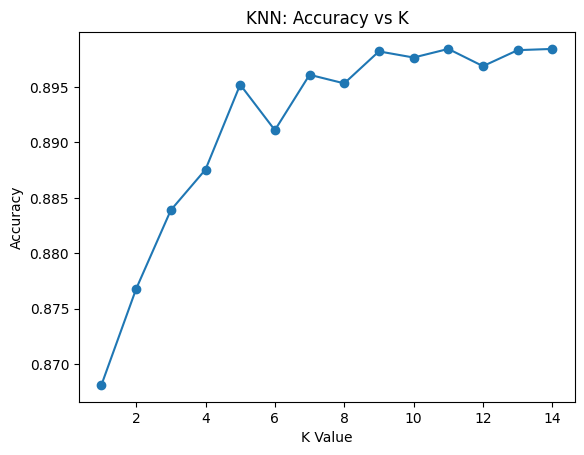

In [22]:
# TODO: KNN
k_range = range(1, 15)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_c_scaled, y_train_c)
    scores.append(knn.score(X_test_c_scaled, y_test_c))

plt.plot(k_range, scores, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN: Accuracy vs K")
plt.show()

## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


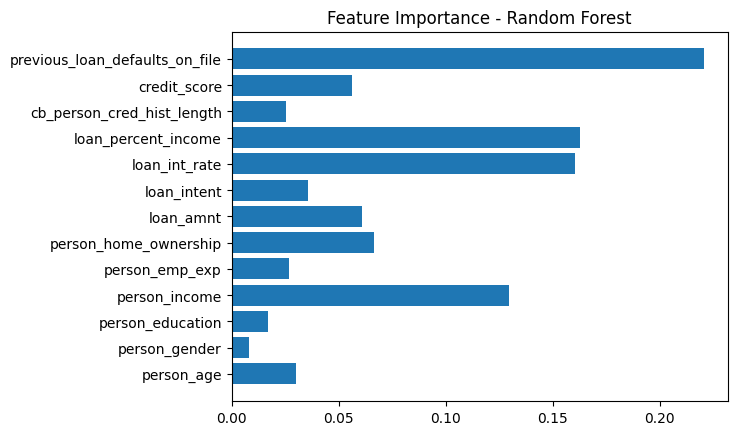

In [23]:
# TODO: Random Forest Classifier
# Using RandomForestClassifier() class
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c, y_train_c)

# Show feature importance
importances = rf_clf.feature_importances_
plt.barh(X_c.columns, importances)
plt.title("Feature Importance - Random Forest")
plt.show()

# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


## TODO: Write your reflection here

#Final Reflection
##Best Regression Model:
 The Random Forest Regressor was the most effective because it handles non-linear patterns much better than linear models and offers better generalization by reducing overfitting.

##Best Classification Model:
 The Random Forest Classifier performed best due to its ensemble nature, which makes predictions more robust and stable against noise in the data.

##Real-world Deployment:
 A great use case is Health Insurance Pricing. This model can automate premium calculations by analyzing key factors like a customer's age, BMI, and smoking status to determine fair and accurate rates.